# 📊 Notebook 01 — Data Understanding & EDA

**Purpose**: Understand the raw dataset structurally and statistically. No transformations — only observe and document.

**Theory**: Lecture 01 — Quality data is the most critical factor for ML success. Lecture 02 Step 1 — Understand the data.

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

os.makedirs('../plots', exist_ok=True)
print('Imports ready.')

Imports ready.


In [2]:
# Cell 2: Load and Inspect
df = pd.read_csv('../data/nev_battery_charging.csv')
print(f'Shape: {df.shape}')
print(f'\nData Types:\n{df.dtypes}')
df.head()

Shape: (1900, 21)

Data Types:
timestamp                 int64
SOC                     float64
SOH                     float64
terminal_voltage        float64
battery_current         float64
battery_temp            float64
ambient_temp            float64
internal_resistance     float64
action_current          float64
action_voltage          float64
dT_dt                   float64
dV_dt                   float64
soc_delta               float64
thermal_stress_index    float64
aging_indicator         float64
charging_efficiency     float64
charging_time             int64
cycle_degradation       float64
over_temp_flag            int64
over_voltage_flag         int64
balancing_time          float64
dtype: object


,timestamp,SOC,SOH,terminal_voltage,battery_current,battery_temp,ambient_temp,internal_resistance,action_current,action_voltage,...,dV_dt,soc_delta,thermal_stress_index,aging_indicator,charging_efficiency,charging_time,cycle_degradation,over_temp_flag,over_voltage_flag,balancing_time
0,0,0.059934,0.867421,2.800000,24.306689,30.253841,39.880384,0.089445,24.152161,2.800000,...,0.000000,0.047235,0.000000,0.216028,0.863980,2371,0.000426,0,0,24.933030
1,1,0.107169,0.993388,2.800000,6.888177,30.363472,15.399988,0.108257,8.014256,2.800000,...,0.031064,0.055094,0.374087,0.086760,0.853122,3479,0.000946,0,0,26.837918
2,2,0.170123,0.897095,2.862128,25.689530,32.066534,25.076428,0.133563,25.343965,2.883569,...,0.000000,0.071707,0.174753,0.338501,0.856608,2839,0.000467,0,0,10.002188
3,3,0.250583,0.983261,2.800000,15.691727,32.269852,35.452532,0.076195,12.142471,2.800000,...,-0.031064,0.062889,0.000000,0.092520,0.849252,2725,0.000567,0,0,14.369082
4,4,0.295900,0.940441,2.800000,19.901598,33.003209,10.612048,0.073659,22.703030,2.830187,...,0.000183,0.045317,0.559779,0.167229,0.829716,3584,0.000689,0,0,2.804287


## 1. Missing Values Analysis

Battery sensor datasets often have zero missing values because sensors either record or fail completely.

In [3]:
# Cell 3: Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
if len(missing_df) == 0:
    print('✅ No missing values in any column.')
else:
    display(missing_df.style.background_gradient(cmap='Reds'))
print(f'Total cells: {df.shape[0]*df.shape[1]}, Missing: {df.isnull().sum().sum()}')

✅ No missing values in any column.
Total cells: 39900, Missing: 0


## 2. Descriptive Statistics

Using extended percentiles (1st and 99th) to catch tail behavior.

In [4]:
# Cell 4: Descriptive Stats
stats = df.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
stats['range'] = stats['max'] - stats['min']
stats.style.background_gradient(cmap='YlOrRd', subset=['range'])

,count,mean,std,min,1%,25%,50%,75%,99%,max,range
timestamp,1900.000000,949.500000,548.627074,0.000000,18.990000,474.750000,949.500000,1424.250000,1880.010000,1899.000000,1899.000000
SOC,1900.000000,48.154233,28.094806,0.059934,0.931263,23.881046,47.952540,72.432345,95.798287,96.753910,96.693976
SOH,1900.000000,0.924552,0.043182,0.850002,0.851487,0.887646,0.924675,0.961590,0.998419,0.999934,0.149932
terminal_voltage,1900.000000,3.473539,0.394720,2.800000,2.800366,3.131540,3.470022,3.810061,4.156026,4.200000,1.400000
battery_current,1900.000000,17.186868,7.186367,5.006025,5.230014,10.973488,16.926272,23.251138,29.658936,29.980182,24.974157
battery_temp,1900.000000,581.868816,311.917184,30.253841,42.489548,315.303105,579.829927,851.818235,1118.137259,1129.491070,1099.237229
ambient_temp,1900.000000,24.809350,8.472867,10.001585,10.277572,17.604701,24.833801,31.956746,39.579758,39.985156,29.983571
internal_resistance,1900.000000,0.085849,0.037897,0.020021,0.021434,0.053180,0.085722,0.119286,0.148686,0.149958,0.129937
action_current,1900.000000,17.133618,7.806316,0.000000,1.368615,10.938281,16.947561,23.326322,32.752129,35.000000,35.000000
action_voltage,1900.000000,3.474594,0.397229,2.800000,2.800000,3.134212,3.473040,3.821057,4.175541,4.200000,1.400000


### 🔍 Key Statistical Findings

| Feature | Observation | Implication |
|---------|------------|-------------|
| SOC | min~0.06, max~97 | **NOT** 0-1 bounded. Percentage or cumulative counter |
| SOH | min~0.86, max~0.99 | Properly bounded 0-1 fraction |
| battery_temp | min~30, max~1129 | ⚠️ Cumulative thermal encoding, NOT session temp |
| cycle_degradation | min~0.0001, max~0.001 | Tiny float range — needs log transform |
| thermal_stress_index | 0 to 1 | Derived & normalized — encodes long-term thermal history |
| internal_resistance | ~0.02 to 0.15 | Milliohm scale |

## 3. Target Variable Analysis

### 3a. Regression Target: `cycle_degradation`

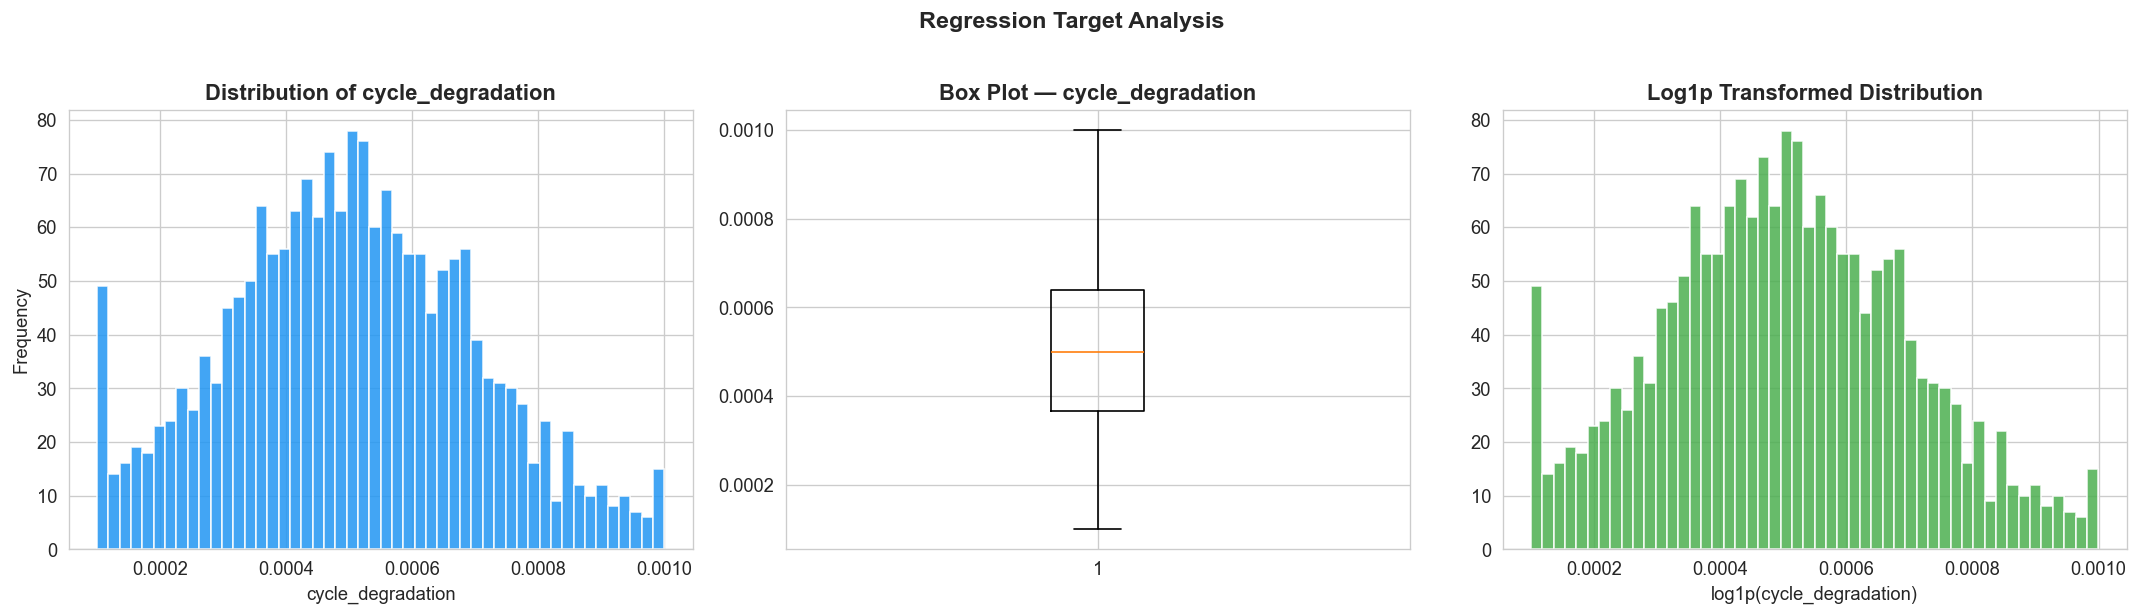

Skewness: 0.122


In [5]:
# Cell 5: cycle_degradation distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['cycle_degradation'], bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of cycle_degradation', fontweight='bold')
axes[0].set_xlabel('cycle_degradation')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['cycle_degradation'], vert=True)
axes[1].set_title('Box Plot — cycle_degradation', fontweight='bold')

# Log-transformed view
axes[2].hist(np.log1p(df['cycle_degradation']), bins=50, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[2].set_title('Log1p Transformed Distribution', fontweight='bold')
axes[2].set_xlabel('log1p(cycle_degradation)')

plt.suptitle('Regression Target Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/eda_regression_target.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Skewness: {df["cycle_degradation"].skew():.3f}')

### 3b. Classification Targets: `over_temp_flag` and `over_voltage_flag`

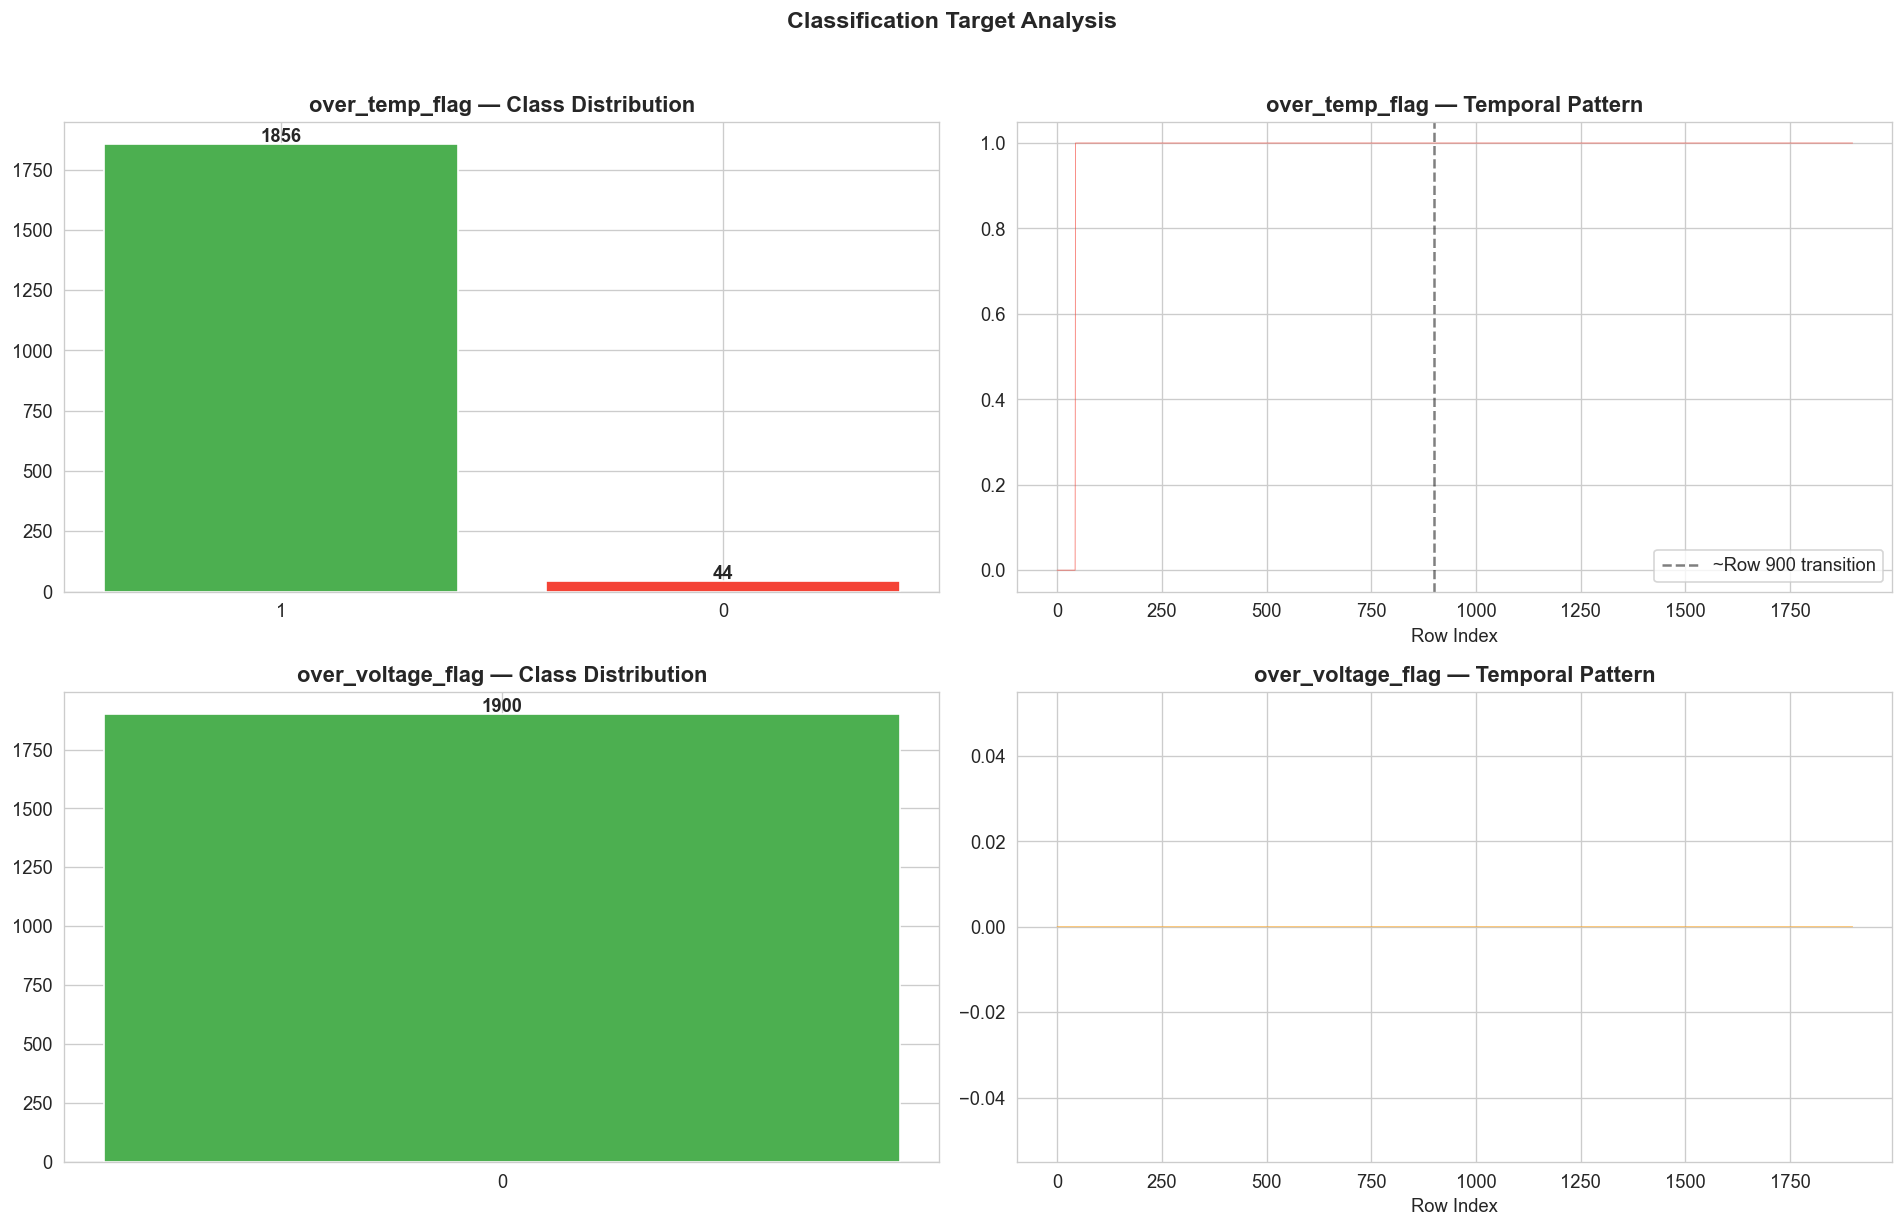

In [6]:
# Cell 6: Classification targets
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# over_temp_flag bar chart
vc_temp = df['over_temp_flag'].value_counts()
axes[0,0].bar(vc_temp.index.astype(str), vc_temp.values, color=['#4CAF50','#F44336'])
axes[0,0].set_title('over_temp_flag — Class Distribution', fontweight='bold')
for i, v in enumerate(vc_temp.values):
    axes[0,0].text(i, v+10, str(v), ha='center', fontweight='bold')

# over_temp_flag temporal pattern
axes[0,1].plot(df.index, df['over_temp_flag'], color='#F44336', alpha=0.7, linewidth=0.5)
axes[0,1].set_title('over_temp_flag — Temporal Pattern', fontweight='bold')
axes[0,1].set_xlabel('Row Index')
axes[0,1].axvline(x=900, color='black', linestyle='--', alpha=0.5, label='~Row 900 transition')
axes[0,1].legend()

# over_voltage_flag bar chart
vc_volt = df['over_voltage_flag'].value_counts()
axes[1,0].bar(vc_volt.index.astype(str), vc_volt.values, color=['#4CAF50','#FF9800'])
axes[1,0].set_title('over_voltage_flag — Class Distribution', fontweight='bold')
for i, v in enumerate(vc_volt.values):
    axes[1,0].text(i, v+10, str(v), ha='center', fontweight='bold')

# over_voltage_flag temporal pattern
axes[1,1].plot(df.index, df['over_voltage_flag'], color='#FF9800', alpha=0.7, linewidth=0.5)
axes[1,1].set_title('over_voltage_flag — Temporal Pattern', fontweight='bold')
axes[1,1].set_xlabel('Row Index')

plt.suptitle('Classification Target Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/eda_classification_targets.png', dpi=150, bbox_inches='tight')
plt.show()

### ⚠️ CRITICAL FINDING

`over_temp_flag` transitions from 0 → 1 around **row ~900** in a temporal block pattern. This means:
- The class split is **temporal, not random**
- Random `train_test_split` would cause **data leakage** (future states in training)
- The test set **must** be the final N rows chronologically

`over_voltage_flag` has extreme class imbalance — nearly all 0. A classifier cannot meaningfully learn from so few positives.

## 4. Feature Distributions

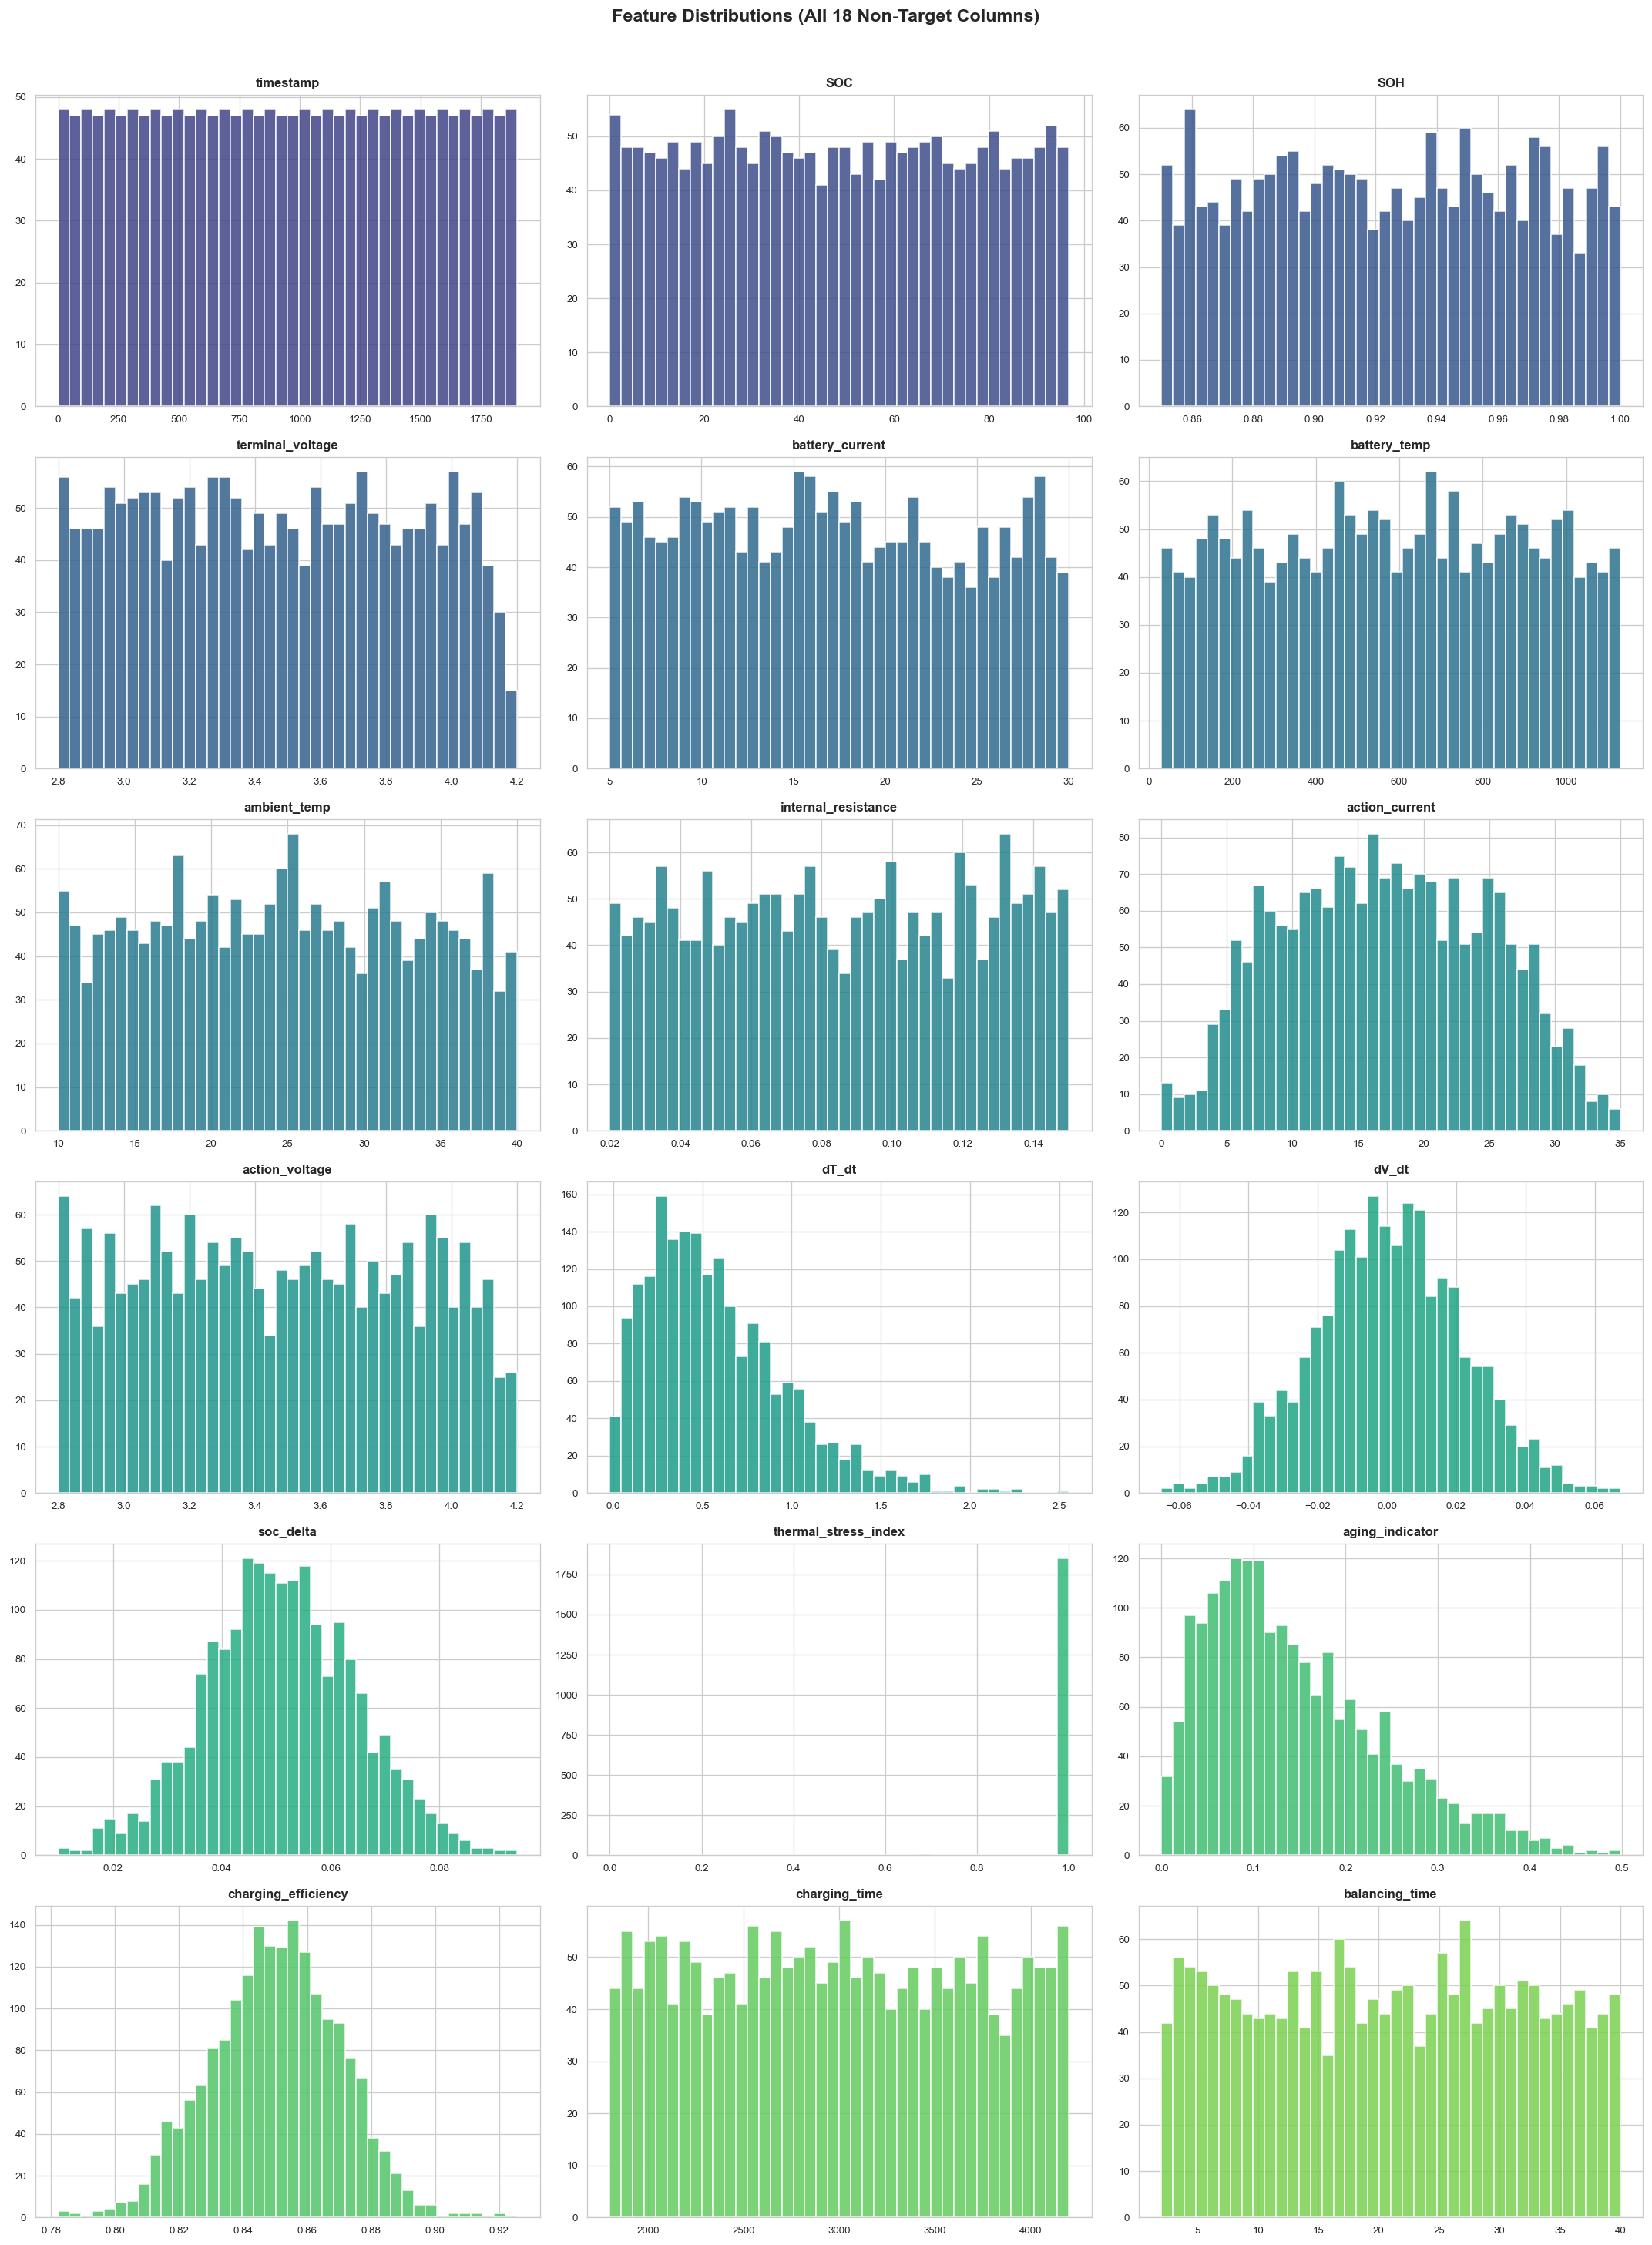

In [7]:
# Cell 7: Feature distributions grid
feature_cols = [c for c in df.columns if c not in ['cycle_degradation','over_temp_flag','over_voltage_flag']]
n_features = len(feature_cols)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes_flat = axes.flatten()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_features))

for i, col in enumerate(feature_cols):
    axes_flat[i].hist(df[col], bins=40, color=colors[i], edgecolor='white', alpha=0.85)
    axes_flat[i].set_title(col, fontweight='bold', fontsize=10)
    axes_flat[i].tick_params(labelsize=8)

# Hide unused subplots
for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Feature Distributions (All 18 Non-Target Columns)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

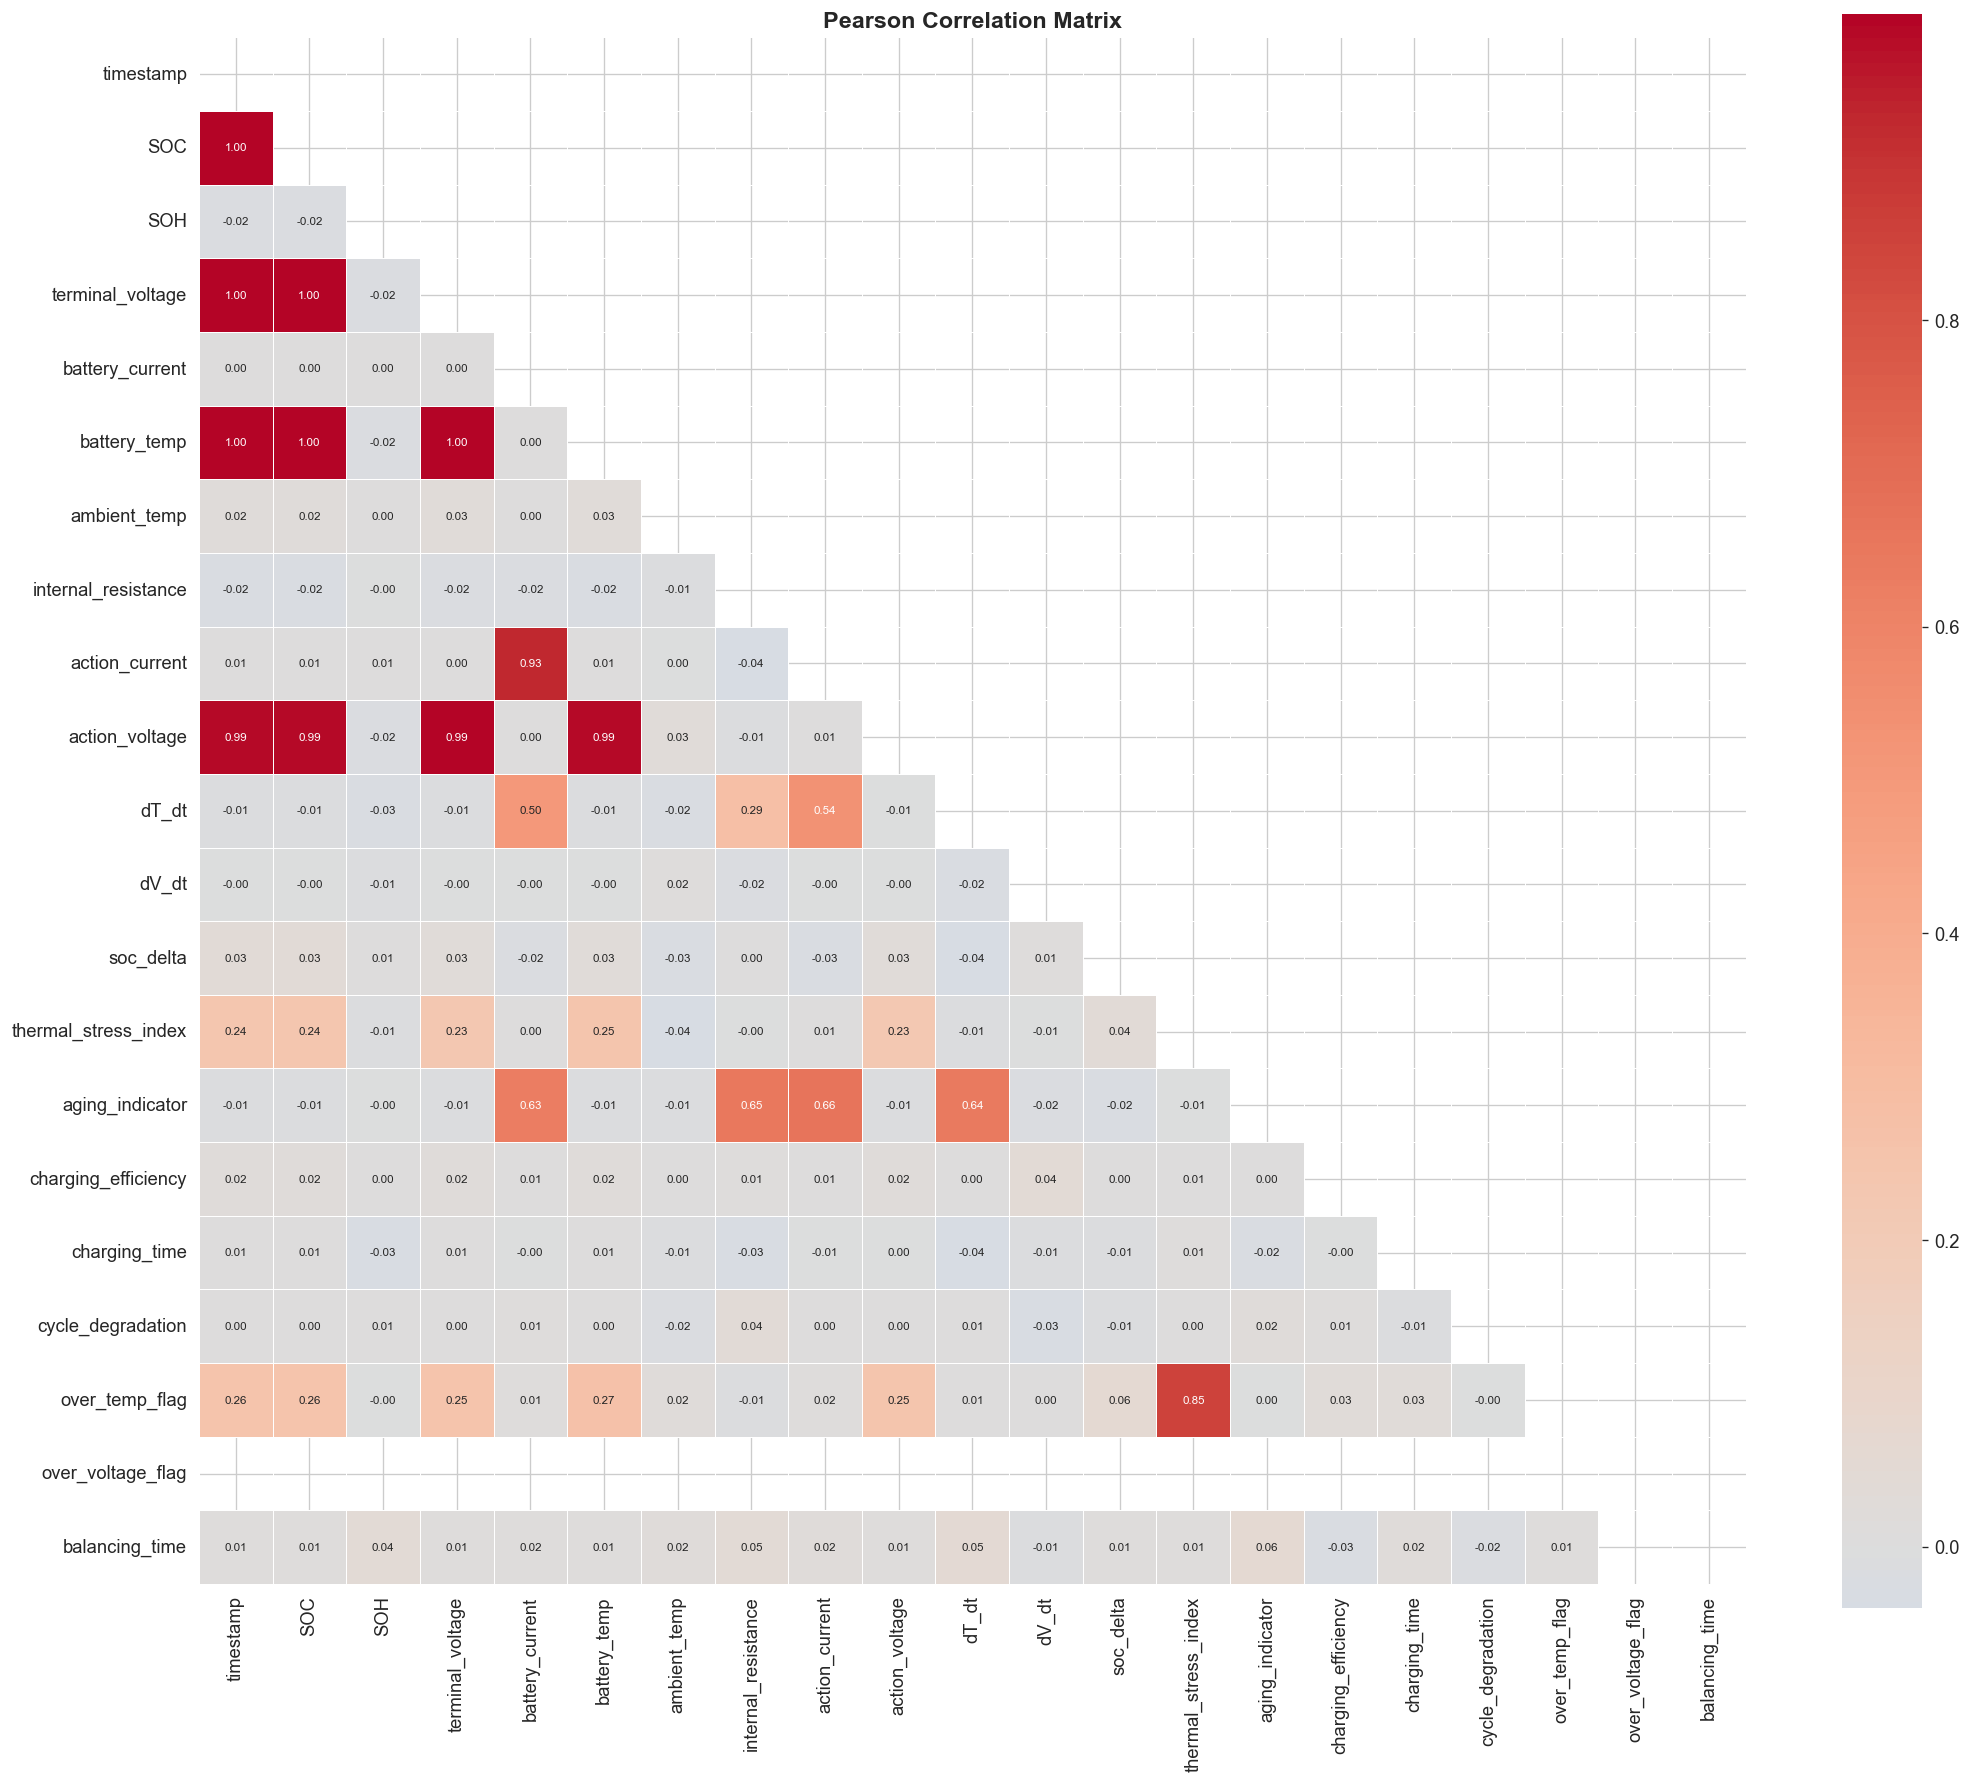


=== Pairs with |correlation| > 0.85 ===
  timestamp <-> SOC: 1.000
  timestamp <-> terminal_voltage: 0.997
  timestamp <-> battery_temp: 1.000
  timestamp <-> action_voltage: 0.990
  SOC <-> terminal_voltage: 0.997
  SOC <-> battery_temp: 1.000
  SOC <-> action_voltage: 0.990
  terminal_voltage <-> battery_temp: 0.997
  terminal_voltage <-> action_voltage: 0.992
  battery_current <-> action_current: 0.927
  battery_temp <-> action_voltage: 0.989
  thermal_stress_index <-> over_temp_flag: 0.851


In [8]:
# Cell 8: Correlation heatmap
corr = df.corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size':7})
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# High correlation pairs
print('\n=== Pairs with |correlation| > 0.85 ===')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.85:
            print(f'  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i,j]:.3f}')

## 6. Time-Series Patterns

Plot key features against row index to reveal longitudinal trends.

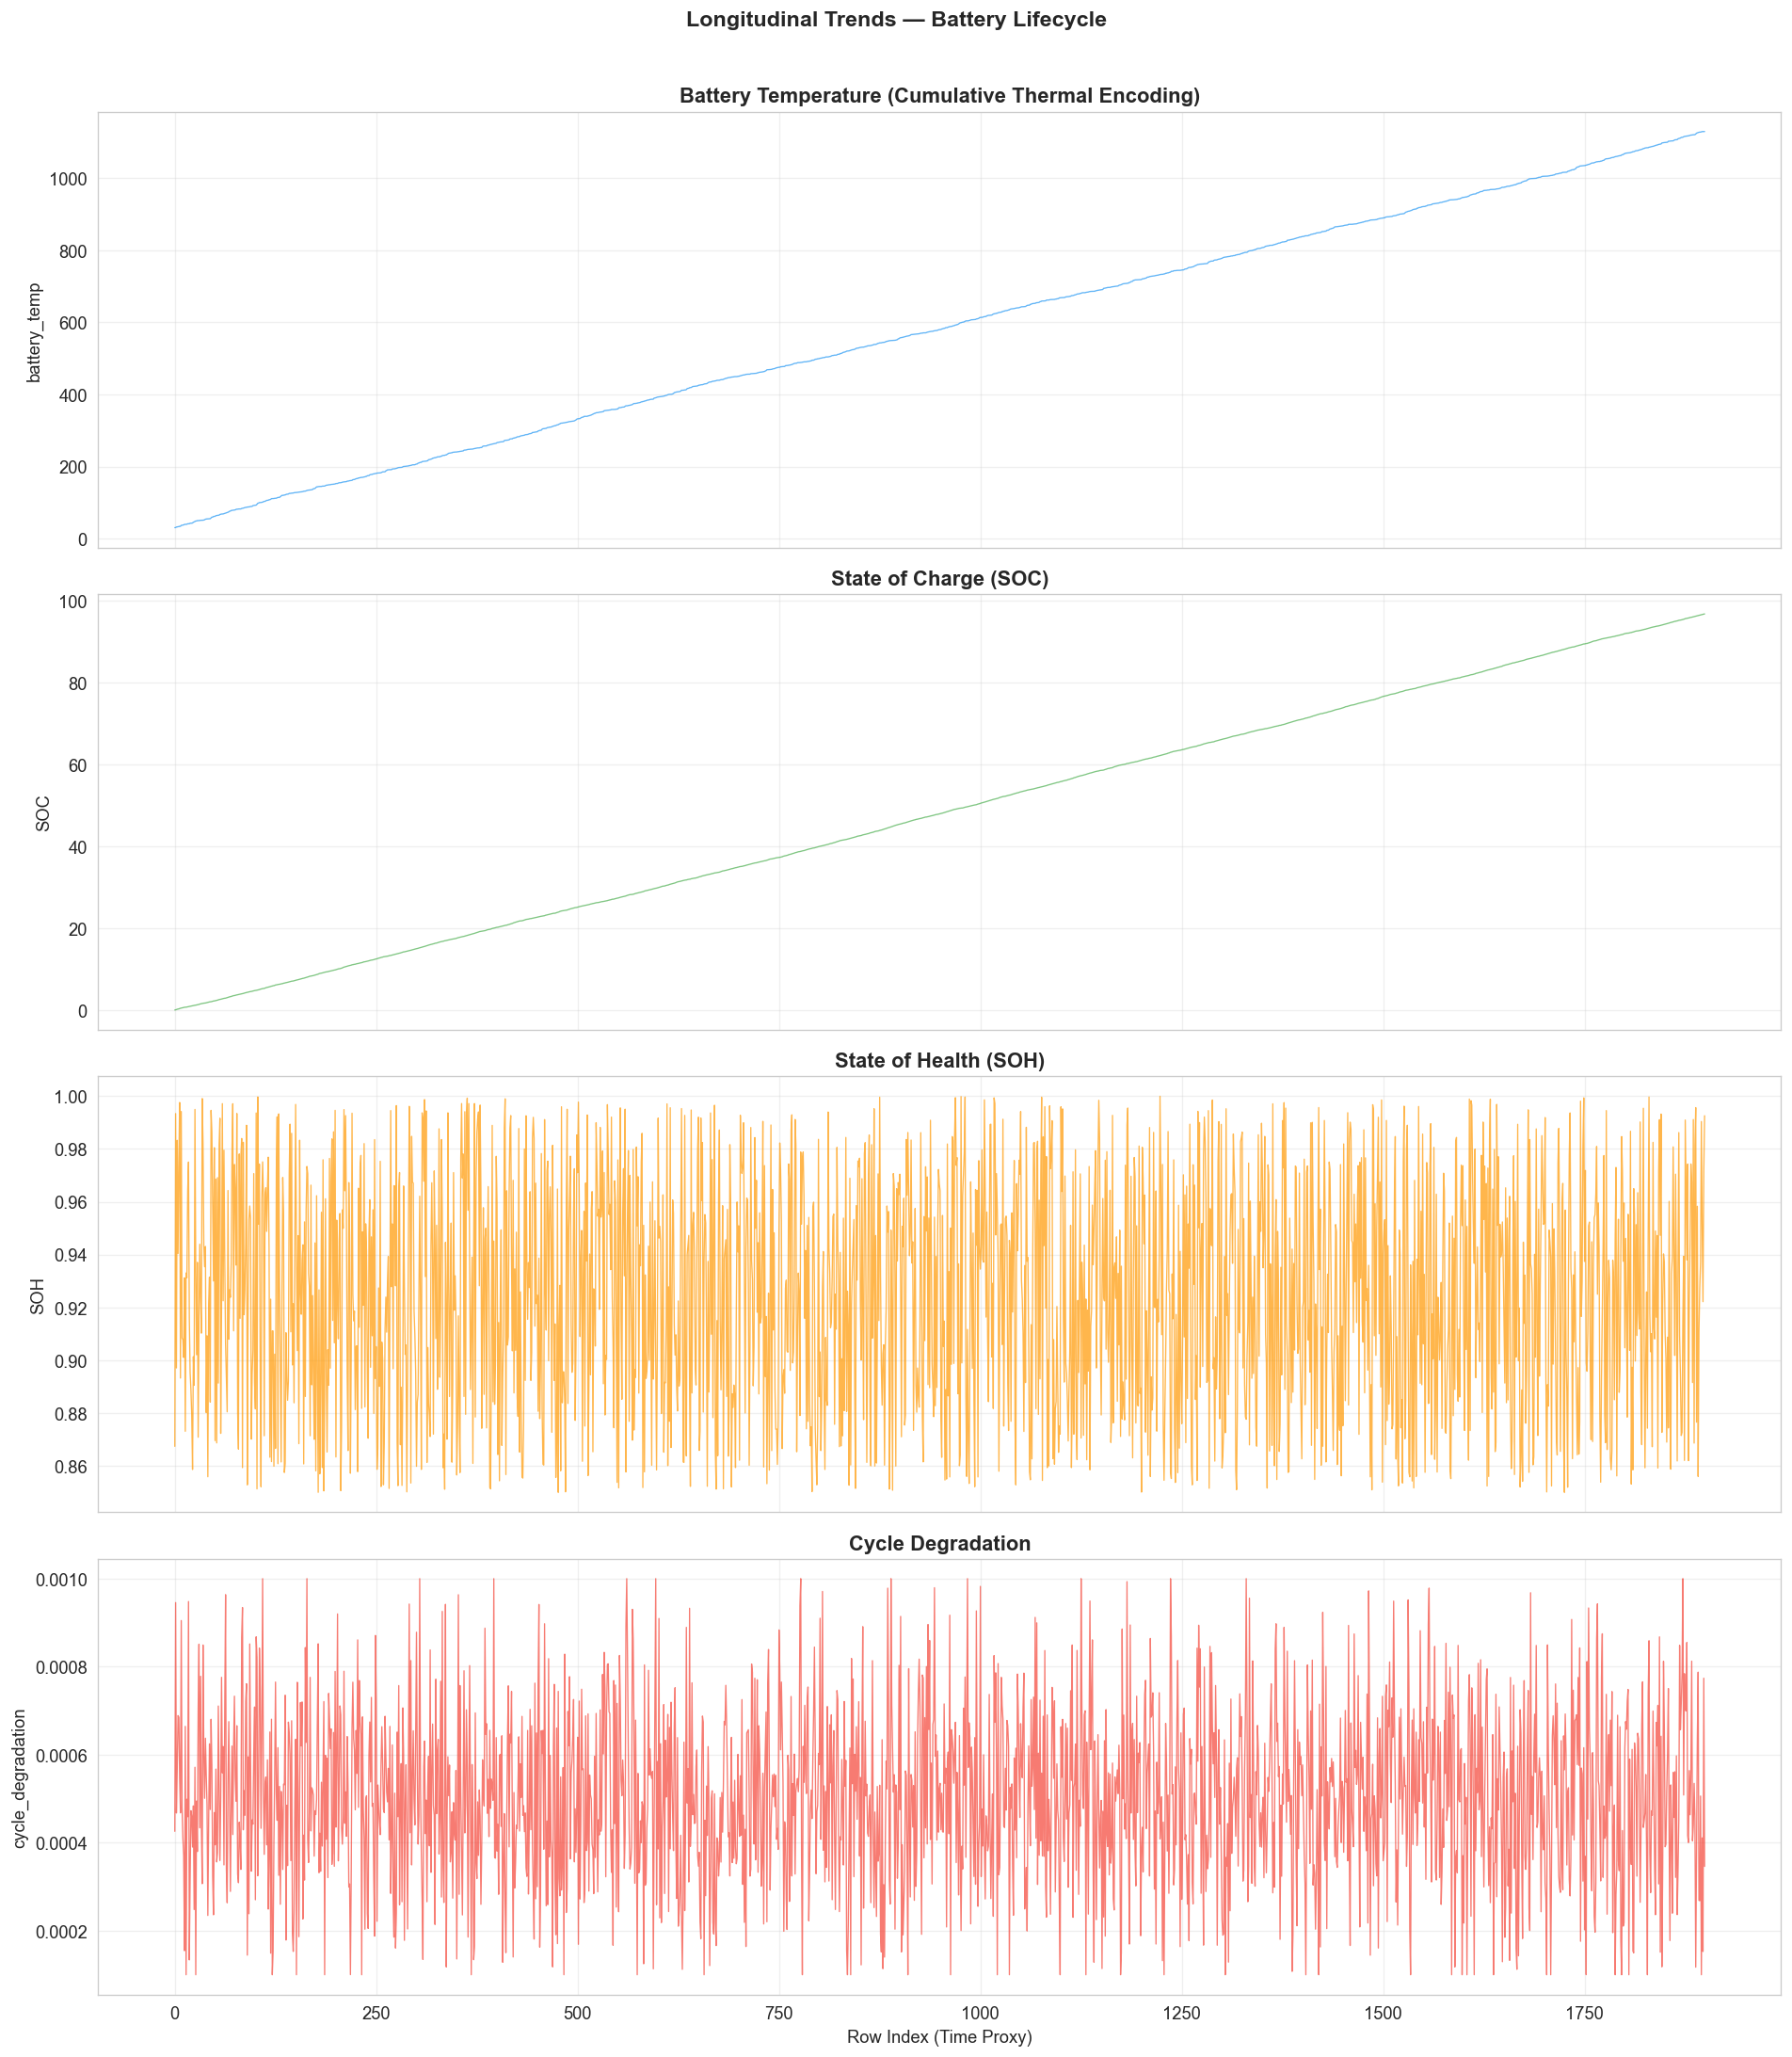

In [9]:
# Cell 9: Time series patterns
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
feats = ['battery_temp', 'SOC', 'SOH', 'cycle_degradation']
titles = ['Battery Temperature (Cumulative Thermal Encoding)',
          'State of Charge (SOC)',
          'State of Health (SOH)',
          'Cycle Degradation']

for ax, feat, title, color in zip(axes, feats, titles, colors):
    ax.plot(df.index, df[feat], color=color, alpha=0.7, linewidth=0.8)
    ax.set_ylabel(feat, fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Row Index (Time Proxy)', fontsize=11)
plt.suptitle('Longitudinal Trends — Battery Lifecycle', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/eda_time_series_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Additional Visualizations

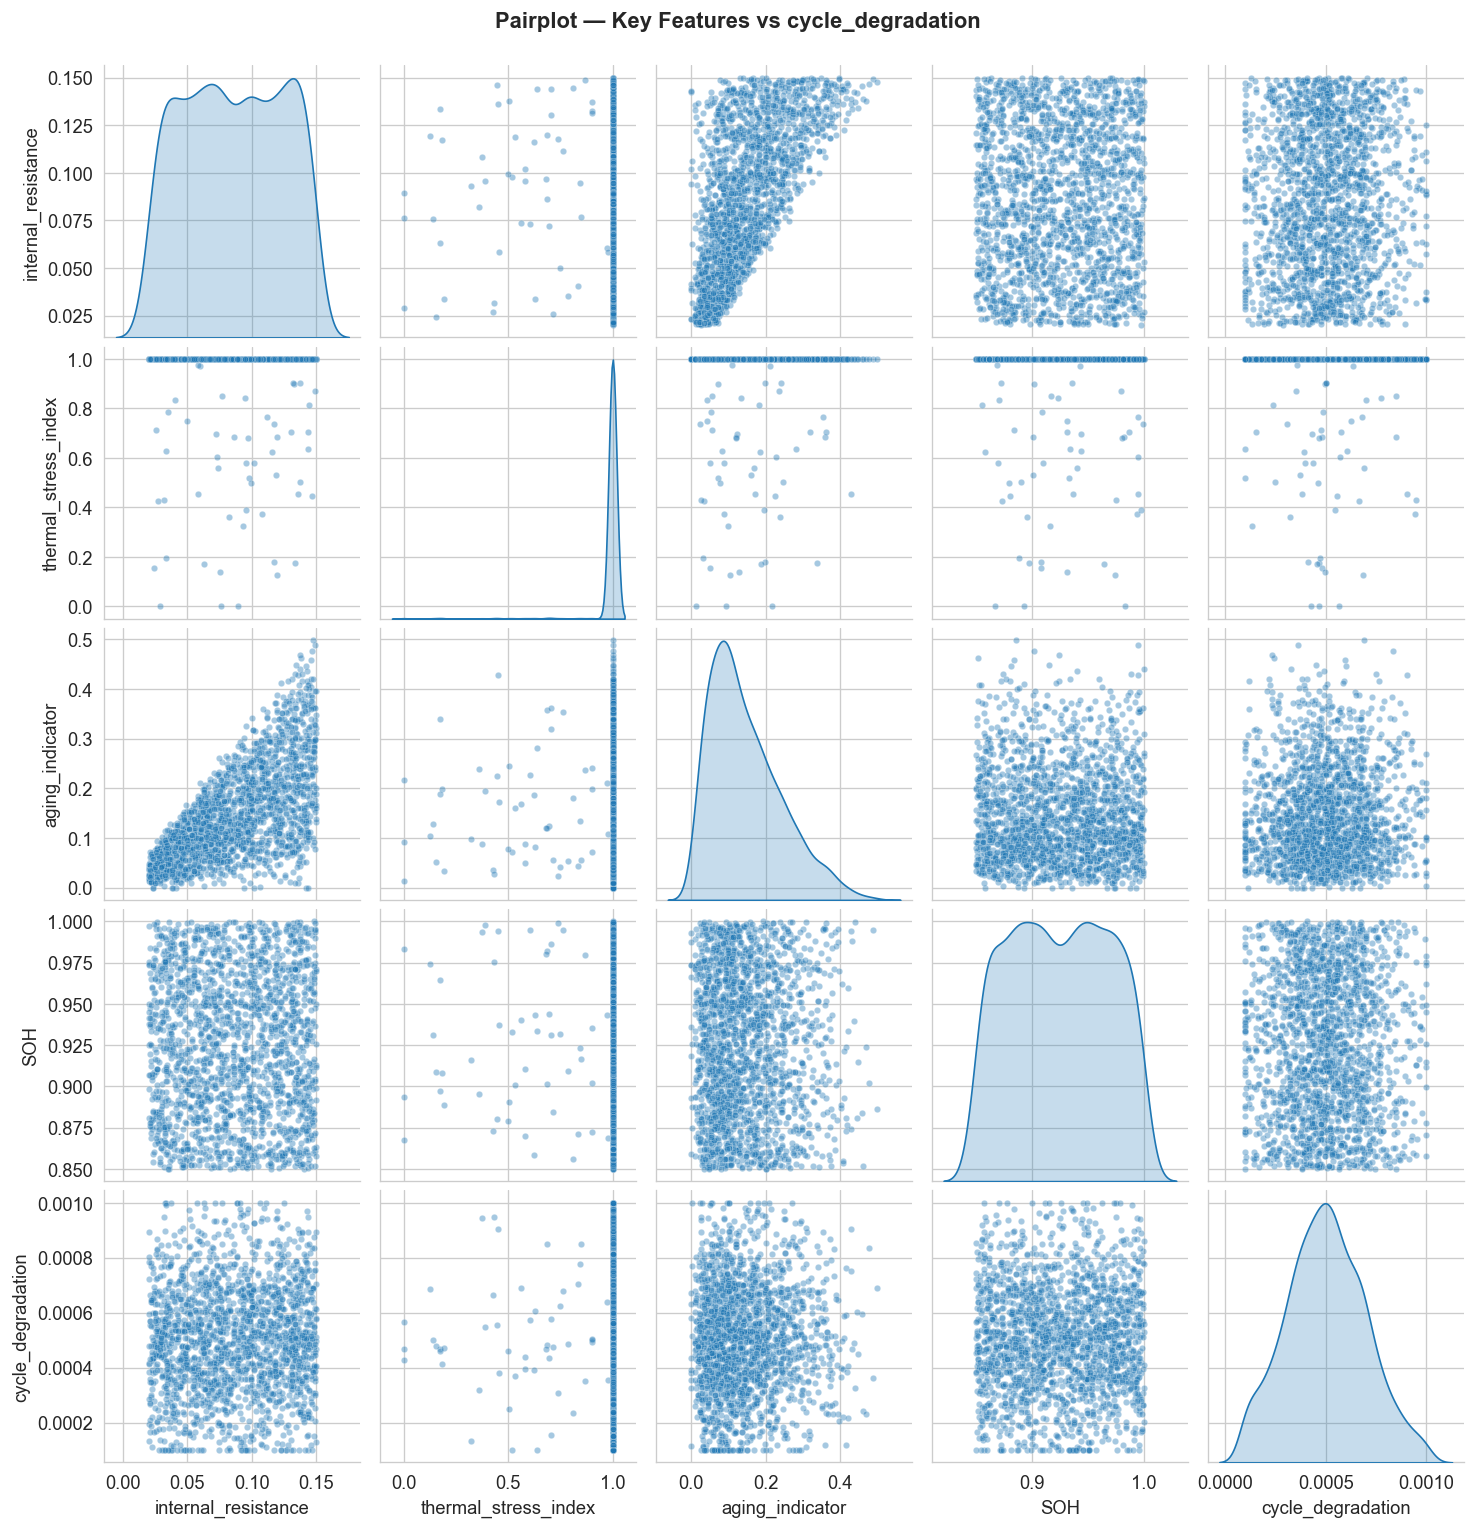

In [10]:
# Cell 10: Pairplot for key features vs cycle_degradation
key_feats = ['internal_resistance', 'thermal_stress_index', 'aging_indicator', 'SOH', 'cycle_degradation']
g = sns.pairplot(df[key_feats], diag_kind='kde', plot_kws={'alpha':0.4, 's':15})
g.fig.suptitle('Pairplot — Key Features vs cycle_degradation', fontweight='bold', y=1.02)
plt.savefig('../plots/eda_pairplot_key_features.png', dpi=150, bbox_inches='tight')
plt.show()

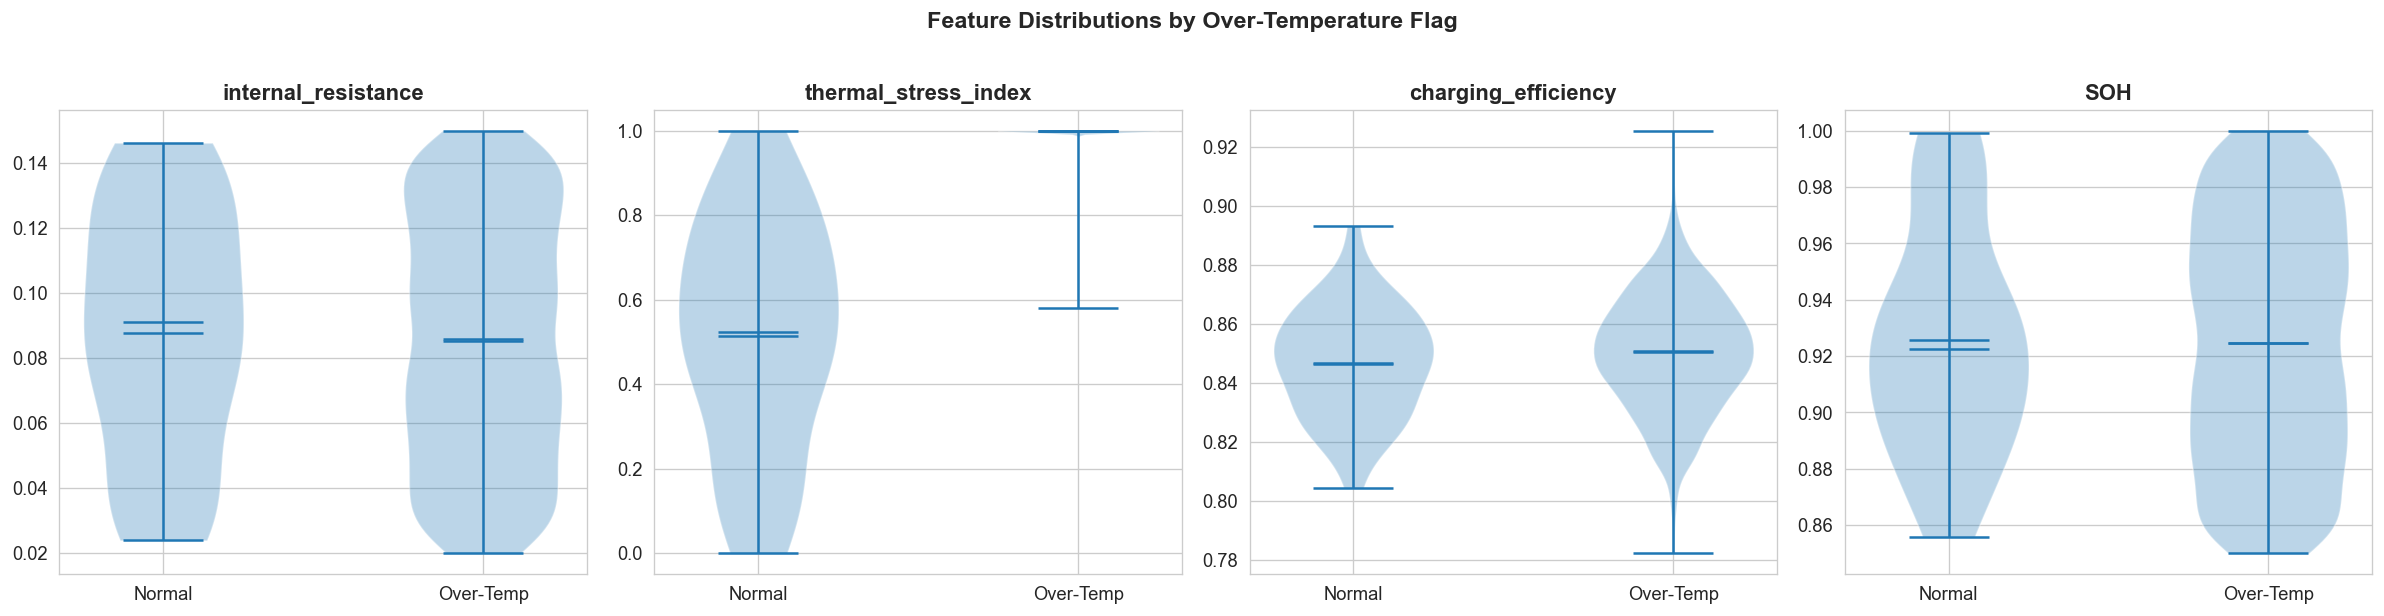

In [11]:
# Cell 11: Violin plots for features by over_temp_flag
key_feats2 = ['internal_resistance', 'thermal_stress_index', 'charging_efficiency', 'SOH']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, feat in zip(axes, key_feats2):
    parts = ax.violinplot([df[df['over_temp_flag']==0][feat].values,
                           df[df['over_temp_flag']==1][feat].values],
                          positions=[0,1], showmeans=True, showmedians=True)
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Normal','Over-Temp'])
    ax.set_title(feat, fontweight='bold')
plt.suptitle('Feature Distributions by Over-Temperature Flag', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/eda_violin_by_overtemp.png', dpi=150, bbox_inches='tight')
plt.show()

## 📋 EDA Summary & Decisions for Notebook 02

| Finding | Decision |
|---------|----------|
| No missing values | Still build imputer into pipeline for inference robustness |
| SOC ranges 0-97 (not 0-1) | StandardScaler will handle this; no manual rescaling needed |
| battery_temp is cumulative thermal proxy (30-1129) | Do NOT normalize like session temp; consider dropping in favor of thermal_stress_index |
| cycle_degradation is right-skewed (0.0001-0.001) | Apply log1p transform before regression |
| over_temp_flag has temporal block pattern | **Must use chronological split**, NOT random |
| over_voltage_flag has extreme imbalance | Use rule-based fallback instead of classifier |
| High correlation pairs identified | Drop one from each pair in feature engineering |
| Derived features already exist in data | Verify before re-engineering |